## Data Cleaning

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
dt=pd.read_excel('mobile_sales_data.xlsx')
dt.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Product                  50000 non-null  str           
 1   Brand                    50000 non-null  str           
 2   Product Code             50000 non-null  object        
 3   Product Specification    50000 non-null  str           
 4   Price                    50000 non-null  int64         
 5   Inward Date              50000 non-null  datetime64[us]
 6   Dispatch Date            50000 non-null  datetime64[us]
 7   Quantity Sold            50000 non-null  int64         
 8   Customer Name            50000 non-null  str           
 9   Customer Location        50000 non-null  str           
 10  Region                   50000 non-null  str           
 11  Core Specification       25017 non-null  str           
 12  Processor Specification  50000 non-null  st

In [3]:
dt.head()

,Product,Brand,Product Code,Product Specification,Price,Inward Date,Dispatch Date,Quantity Sold,Customer Name,Customer Location,Region,Core Specification,Processor Specification,RAM,ROM,SSD
0,Mobile Phone,Motorola,88EB4558,Site candidate activity company there bit insi...,78570,2023-08-02,2023-08-03,6,William Hess,South Kelsey,Central,NaN,Snapdragon 7 Gen,12GB,128GB,NaN
1,Laptop,Oppo,416DFEEB,Beat put care fight affect address his.,44613,2023-10-03,2023-10-06,1,Larry Smith,North Lisa,South,Ryzen 5,Ryzen 5,8GB,512GB,256GB
2,Mobile Phone,Samsung,9F975B08,Energy special low seven place audience.,159826,2025-03-19,2025-03-20,5,Leah Copeland,South Todd,Central,NaN,MediaTek Dimensity,8GB,256GB,NaN
3,Laptop,Sony,73D2A7CC,Friend record hard contain minute we role sea ...,20911,2024-02-06,2024-03-27,1,Dan Kirby,New Jordanmouth,South,i7,i7,12GB,64GB,2TB
4,Laptop,Microsoft,CCE0B80D,Program recently feeling save tree hotel people.,69832,2023-08-10,2023-09-10,4,Dean Martin,Keithton,East,i7,i7,8GB,128GB,2TB


In [4]:
dt.tail()

,Product,Brand,Product Code,Product Specification,Price,Inward Date,Dispatch Date,Quantity Sold,Customer Name,Customer Location,Region,Core Specification,Processor Specification,RAM,ROM,SSD
49995,Laptop,Motorola,8C187637,Pick build kind teach mean each camera.,170385,2024-03-02,2024-04-11,6,Sara Gomez,Sylviatown,North,i3,i3,16GB,512GB,2TB
49996,Laptop,HP,0DA9E4D3,Outside policy treat he opportunity pattern.,193133,2025-01-19,2025-01-20,4,Raymond Clark,Chrismouth,West,i7,i7,8GB,1TB,512GB
49997,Laptop,Toshiba,CAD89A93,Test floor tax together out adult discover own...,66502,2024-01-16,2024-03-05,6,Joseph Martin,Huntfurt,North,i5,i5,4GB,64GB,2TB
49998,Mobile Phone,Lenovo,78566C17,Away also magazine receive such lay.,158883,2023-05-15,2023-05-25,2,Gabrielle Barnett,Heidiberg,North,NaN,Snapdragon 7s,12GB,1TB,NaN
49999,Laptop,Asus,9C3FC57C,Role ahead common listen idea few blood half.,86483,2023-08-29,2023-10-26,7,Robert Sampson,West Elizabethchester,East,i7,i7,12GB,128GB,256GB


In [5]:
dt.isnull().sum()

Product                        0
Brand                          0
Product Code                   0
Product Specification          0
Price                          0
Inward Date                    0
Dispatch Date                  0
Quantity Sold                  0
Customer Name                  0
Customer Location              0
Region                         0
Core Specification         24983
Processor Specification        0
RAM                            0
ROM                            0
SSD                        24983
dtype: int64

In [6]:
dt.loc[(dt['Product'] == 'Mobile Phone') & (dt['SSD'].isna()), 'SSD'] ='256GB'
dt.loc[(dt['Product'] == 'Laptop') & (dt['SSD'].isna()), 'SSD'] = '1TB'
dt.isnull().sum()

Product                        0
Brand                          0
Product Code                   0
Product Specification          0
Price                          0
Inward Date                    0
Dispatch Date                  0
Quantity Sold                  0
Customer Name                  0
Customer Location              0
Region                         0
Core Specification         24983
Processor Specification        0
RAM                            0
ROM                            0
SSD                            0
dtype: int64

In [7]:
dt['Core Specification'].max()
dt['Core Specification']=dt['Core Specification'].fillna('i9')
dt.isnull().sum()

Product                    0
Brand                      0
Product Code               0
Product Specification      0
Price                      0
Inward Date                0
Dispatch Date              0
Quantity Sold              0
Customer Name              0
Customer Location          0
Region                     0
Core Specification         0
Processor Specification    0
RAM                        0
ROM                        0
SSD                        0
dtype: int64

In [8]:
dt['Region']=dt['Region'].map({
    'Central' : '01', 
    'South' : '02',
    'East' : '03', 
    'North' : '04', 
    'West' : '05'
})
dt['Region']=dt['Region'].astype('int64')
dt.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Product                  50000 non-null  str           
 1   Brand                    50000 non-null  str           
 2   Product Code             50000 non-null  object        
 3   Product Specification    50000 non-null  str           
 4   Price                    50000 non-null  int64         
 5   Inward Date              50000 non-null  datetime64[us]
 6   Dispatch Date            50000 non-null  datetime64[us]
 7   Quantity Sold            50000 non-null  int64         
 8   Customer Name            50000 non-null  str           
 9   Customer Location        50000 non-null  str           
 10  Region                   50000 non-null  int64         
 11  Core Specification       50000 non-null  str           
 12  Processor Specification  50000 non-null  st

In [9]:
dt['Core Specification']=dt['Core Specification'].map({
    'i9' : '50', 
    'Ryzen 5' : '51',
    'i7' : '52', 
    'i5' : '53',
    'Ryzen 3' : '54', 
    'i3' : '55', 
    'Ryzen 7' : '56', 
    'Ryzen 9' : '57'
})
dt.info()
dt['Core Specification']=dt['Core Specification'].astype('int64')

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Product                  50000 non-null  str           
 1   Brand                    50000 non-null  str           
 2   Product Code             50000 non-null  object        
 3   Product Specification    50000 non-null  str           
 4   Price                    50000 non-null  int64         
 5   Inward Date              50000 non-null  datetime64[us]
 6   Dispatch Date            50000 non-null  datetime64[us]
 7   Quantity Sold            50000 non-null  int64         
 8   Customer Name            50000 non-null  str           
 9   Customer Location        50000 non-null  str           
 10  Region                   50000 non-null  int64         
 11  Core Specification       50000 non-null  str           
 12  Processor Specification  50000 non-null  st

In [10]:
dt.set_index('Product Code')

,Product,Brand,Product Specification,Price,Inward Date,Dispatch Date,Quantity Sold,Customer Name,Customer Location,Region,Core Specification,Processor Specification,RAM,ROM,SSD
Product Code,,,,,,,,,,,,,,,
88EB4558,Mobile Phone,Motorola,Site candidate activity company there bit insi...,78570,2023-08-02,2023-08-03,6,William Hess,South Kelsey,1,50,Snapdragon 7 Gen,12GB,128GB,256GB
416DFEEB,Laptop,Oppo,Beat put care fight affect address his.,44613,2023-10-03,2023-10-06,1,Larry Smith,North Lisa,2,51,Ryzen 5,8GB,512GB,256GB
9F975B08,Mobile Phone,Samsung,Energy special low seven place audience.,159826,2025-03-19,2025-03-20,5,Leah Copeland,South Todd,1,50,MediaTek Dimensity,8GB,256GB,256GB
73D2A7CC,Laptop,Sony,Friend record hard contain minute we role sea ...,20911,2024-02-06,2024-03-27,1,Dan Kirby,New Jordanmouth,2,52,i7,12GB,64GB,2TB
CCE0B80D,Laptop,Microsoft,Program recently feeling save tree hotel people.,69832,2023-08-10,2023-09-10,4,Dean Martin,Keithton,3,52,i7,8GB,128GB,2TB
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8C187637,Laptop,Motorola,Pick build kind teach mean each camera.,170385,2024-03-02,2024-04-11,6,Sara Gomez,Sylviatown,4,55,i3,16GB,512GB,2TB
0DA9E4D3,Laptop,HP,Outside policy treat he opportunity pattern.,193133,2025-01-19,2025-01-20,4,Raymond Clark,Chrismouth,5,52,i7,8GB,1TB,512GB
CAD89A93,Laptop,Toshiba,Test floor tax together out adult discover own...,66502,2024-01-16,2024-03-05,6,Joseph Martin,Huntfurt,4,53,i5,4GB,64GB,2TB


## Visualization of Data

C:\Users\acer\AppData\Local\Temp\ipykernel_2928\1279108808.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=dt,x='Product',y='Quantity Sold',palette=['Cyan','Purple'])


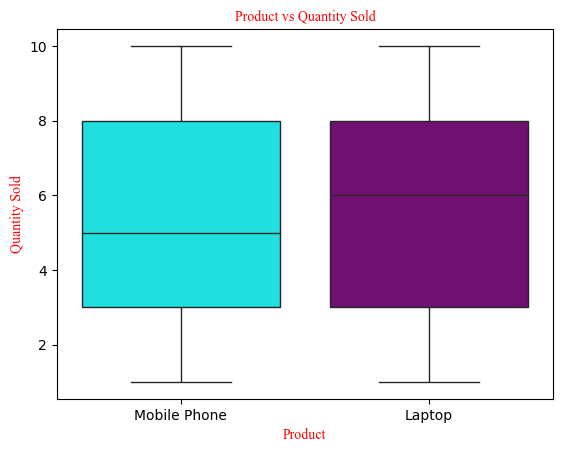

In [11]:
sns.boxplot(data=dt,x='Product',y='Quantity Sold',palette=['Cyan','Purple'])
plt.title('Product vs Quantity Sold',color='Red',font='Times New Roman')
plt.xlabel('Product',color='Red',font='Times New Roman')
plt.ylabel('Quantity Sold',color='Red',font='Times New Roman')
plt.show()

C:\Users\acer\AppData\Local\Temp\ipykernel_2928\1582213017.py:1: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(data=dt,x='Product',y='Region',palette='Magenta',marker='o',linestyle=':')


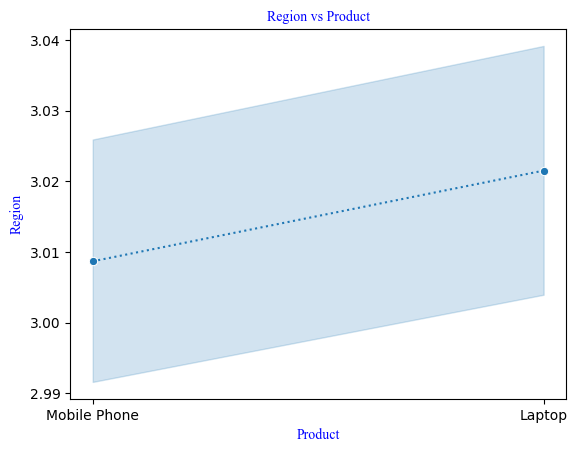

In [12]:
sns.lineplot(data=dt,x='Product',y='Region',palette='Magenta',marker='o',linestyle=':')
plt.title('Region vs Product',color='Blue',font='Times New Roman')
plt.xlabel('Product',color='Blue',font='Times New Roman')
plt.ylabel('Region',color='Blue',font='Times New Roman')
plt.show()

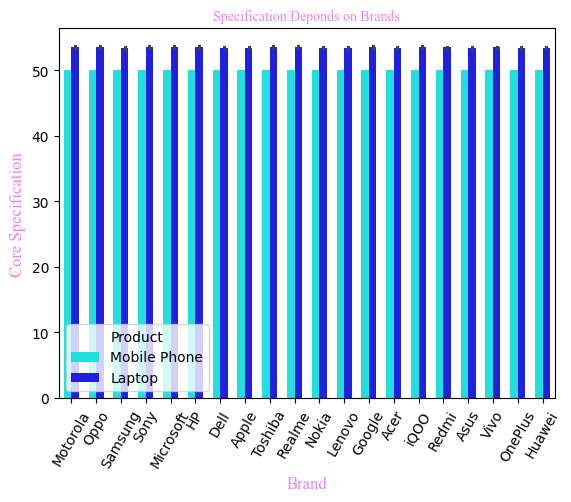

In [13]:
sns.barplot(data=dt,x='Brand',y='Core Specification',hue='Product',width=0.6,palette=['Cyan','Blue'])
plt.title('Specification Deponds on Brands', fontsize=16, font='Times New Roman', color='Violet')
plt.xlabel('Brand', fontsize=12, font='Times New Roman', color='Violet')
plt.ylabel('Core Specification', fontsize=12, font='Times New Roman', color='Violet')
plt.xticks(rotation=60)
plt.show()

C:\Users\acer\AppData\Local\Temp\ipykernel_2928\164518214.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=Avg_Price.index, y=Avg_Price.values, width=0.6,palette=['Yellow','Black'])
C:\Users\acer\AppData\Local\Temp\ipykernel_2928\164518214.py:2: UserWarning: 
The palette list has fewer values (2) than needed (20) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(x=Avg_Price.index, y=Avg_Price.values, width=0.6,palette=['Yellow','Black'])


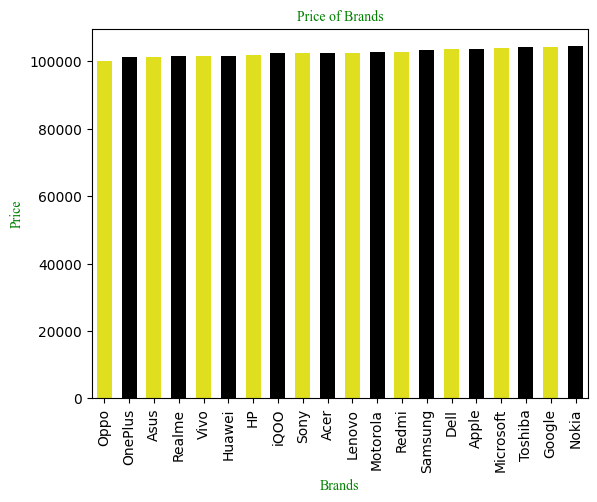

In [14]:
Avg_Price=dt.groupby('Brand')['Price'].mean().sort_values()
sns.barplot(x=Avg_Price.index, y=Avg_Price.values, width=0.6,palette=['Yellow','Black'])
plt.title('Price of Brands',color='Green',font='Times New Roman')
plt.xlabel('Brands',font='Times New Roman',color='Green')
plt.ylabel('Price',font='Times New Roman',color='Green')
plt.xticks(rotation=90)
plt.show()

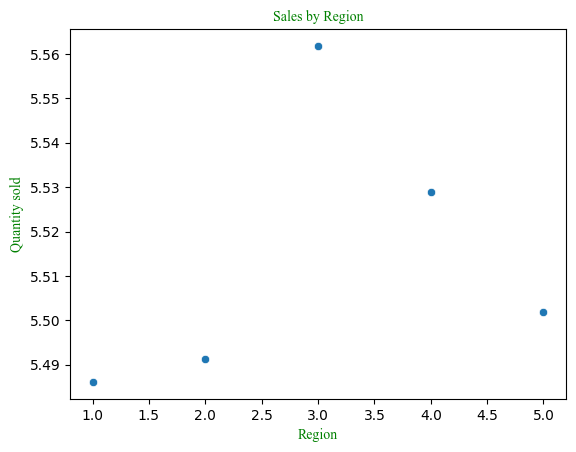

In [17]:
Avg_Sold=dt.groupby('Region')['Quantity Sold'].mean().sort_values()
sns.scatterplot(x=Avg_Sold.index, y=Avg_Sold.values)
plt.title('Sales by Region',color='Green',font='Times New Roman')
plt.xlabel('Region',font='Times New Roman',color='Green')
plt.ylabel('Quantity sold',font='Times New Roman',color='Green')
plt.show()